# 1. Importaciones

In [1]:
# Importaciones
# En Google Colab, ejecuta una sola vez:
# %pip install -q "ultralytics>=8.3.0" opencv-python-headless pillow pandas matplotlib seaborn

import json
import random
import shutil
import sys
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from PIL import Image
from ultralytics import YOLO
import torch

print('Python:', sys.version)
print('Torch:', torch.__version__)
print('CUDA disponible:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Python: 3.13.0 (main, Sep 11 2026, 18:34:43) [GCC 15.2.0]
Torch: 2.11.0+cu128
CUDA disponible: True
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


# 2. Configuracion de rutas y parametros del dataset

In [2]:
PROJECT_CANDIDATES = [Path('/content/Huevos'), Path('/home/lukga/Programacion/CienciaDeDatos/clase/Huevos'), Path.cwd() / 'Huevos']
PROJECT_ROOT = next((candidate for candidate in PROJECT_CANDIDATES if (candidate / 'models').is_dir()), PROJECT_CANDIDATES[0])
DATA_ROOT = PROJECT_ROOT / 'models' / 'Data'
DATASET_ROOT = PROJECT_ROOT / 'models' / 'yolo_dataset_final_holdout'
FINAL_TEST_ROOT = PROJECT_ROOT / 'final_test_holdout'
RUNS_ROOT = PROJECT_ROOT / 'runs_colab'
OUTPUT_ROOT = PROJECT_ROOT / 'top_models'
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
TARGET_CLASS_IDS = {0, 1}
CLASS_NAMES = ['clase_0', 'clase_1']
SEED = 42
FINAL_TEST_RATIO = 0.20
INNER_VAL_RATIO = 0.20
REBUILD_DATASET = True

# 3. Preparacion y validacion de los datos

In [3]:
# 3. Preparacion y validacion de los datos
if not (DATA_ROOT / 'images').is_dir() or not (DATA_ROOT / 'labels').is_dir():
    raise FileNotFoundError(f'Se esperan las carpetas {DATA_ROOT / "images"} y {DATA_ROOT / "labels"}.')
for directory in (DATASET_ROOT, FINAL_TEST_ROOT, RUNS_ROOT, OUTPUT_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

# Convertir todas las imagenes originales de Data a blanco y negro antes de separarlas.
converted_images = 0
for image_path in sorted((DATA_ROOT / 'images').iterdir()):
    if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
        continue
    image = cv2.imread(str(image_path))
    if image is None:
        print(f'No se pudo leer: {image_path}')
        continue
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    if not cv2.imwrite(str(image_path), gray_image):
        raise OSError(f'No se pudo guardar la imagen convertida: {image_path}')
    converted_images += 1
print(f'Imagenes de Data convertidas a blanco y negro: {converted_images}')


def read_yolo_label(label_path):
    normalized = []
    observed_classes = set()
    for line_number, line in enumerate(label_path.read_text().splitlines(), 1):
        values = line.split()
        if not values:
            continue
        if len(values) < 5:
            raise ValueError(f'{label_path.name}:{line_number}: se esperan al menos 5 valores')
        class_id = int(values[0])
        coordinates = [float(value) for value in values[1:]]
        if class_id not in TARGET_CLASS_IDS or any(value < 0 or value > 1 for value in coordinates):
            raise ValueError(f'{label_path.name}:{line_number}: etiqueta fuera de rango')
        if len(coordinates) == 4:
            center_x, center_y, width, height = coordinates
        elif len(coordinates) >= 6 and len(coordinates) % 2 == 0:
            x_values, y_values = coordinates[::2], coordinates[1::2]
            center_x = (min(x_values) + max(x_values)) / 2
            center_y = (min(y_values) + max(y_values)) / 2
            width, height = max(x_values) - min(x_values), max(y_values) - min(y_values)
        else:
            raise ValueError(f'{label_path.name}:{line_number}: formato YOLO invalido')
        if width <= 0 or height <= 0:
            raise ValueError(f'{label_path.name}:{line_number}: bounding box vacia')
        normalized.append(f'{class_id} {center_x:.8f} {center_y:.8f} {width:.8f} {height:.8f}')
        observed_classes.add(class_id)
    return normalized, observed_classes


label_paths = {path.stem: path for path in (DATA_ROOT / 'labels').glob('*.txt')}
pairs = []
class_counts = Counter()
for image_path in sorted((DATA_ROOT / 'images').iterdir()):
    if image_path.suffix.lower() not in IMAGE_EXTENSIONS or image_path.stem not in label_paths:
        continue
    labels, observed_classes = read_yolo_label(label_paths[image_path.stem])
    with Image.open(image_path) as image:
        image.verify()
    pairs.append((image_path, labels))
    class_counts.update(observed_classes)
if not pairs:
    raise RuntimeError('No se encontraron pares imagen/etiqueta validos.')
print(f'Pares validos: {len(pairs)}')
print('Objetos por clase:', {CLASS_NAMES[index]: class_counts[index] for index in sorted(class_counts)})

shuffled = pairs.copy()
random.Random(SEED).shuffle(shuffled)
final_test_count = max(1, round(len(shuffled) * FINAL_TEST_RATIO))
final_test_pairs, training_pairs = shuffled[:final_test_count], shuffled[final_test_count:]
if len(training_pairs) < 2:
    raise RuntimeError('Se necesitan al menos dos imagenes fuera del conjunto final.')
if DATASET_ROOT.exists():
    shutil.rmtree(DATASET_ROOT)
for split in ('train', 'val'):
    (DATASET_ROOT / 'images' / split).mkdir(parents=True)
    (DATASET_ROOT / 'labels' / split).mkdir(parents=True)
random.Random(SEED).shuffle(training_pairs)
val_count = max(1, round(len(training_pairs) * INNER_VAL_RATIO))
split_pairs = {'val': training_pairs[:val_count], 'train': training_pairs[val_count:]}
for split, items in split_pairs.items():
    for image_path, labels in items:
        shutil.copy2(image_path, DATASET_ROOT / 'images' / split / image_path.name)
        (DATASET_ROOT / 'labels' / split / f'{image_path.stem}.txt').write_text('\n'.join(labels) + '\n')

if FINAL_TEST_ROOT.exists():
    shutil.rmtree(FINAL_TEST_ROOT)
(FINAL_TEST_ROOT / 'images').mkdir(parents=True)
(FINAL_TEST_ROOT / 'labels').mkdir(parents=True)
for image_path, labels in final_test_pairs:
    shutil.copy2(image_path, FINAL_TEST_ROOT / 'images' / image_path.name)
    (FINAL_TEST_ROOT / 'labels' / f'{image_path.stem}.txt').write_text('\n'.join(labels) + '\n')
for root, train_path, val_path in ((DATASET_ROOT, 'images/train', 'images/val'), (FINAL_TEST_ROOT, 'images', 'images')):
    (root / 'dataset.yaml').write_text('\n'.join([f'path: {root.resolve().as_posix()}', f'train: {train_path}', f'val: {val_path}', f'test: {val_path}', f'nc: {len(CLASS_NAMES)}', 'names:', *[f'  {index}: {name}' for index, name in enumerate(CLASS_NAMES)]]) + '\n')
print(f'Entrenamiento + validacion: {len(training_pairs)}')
print(f'Evaluacion final aislada: {len(final_test_pairs)}')

Imagenes de Data convertidas a blanco y negro: 899
Pares validos: 899
Objetos por clase: {'clase_0': 479, 'clase_1': 420}
Entrenamiento + validacion: 719
Evaluacion final aislada: 180


# 4. Visualizacion de imagenes y etiquetas

Se muestran 10 imagenes aleatorias.


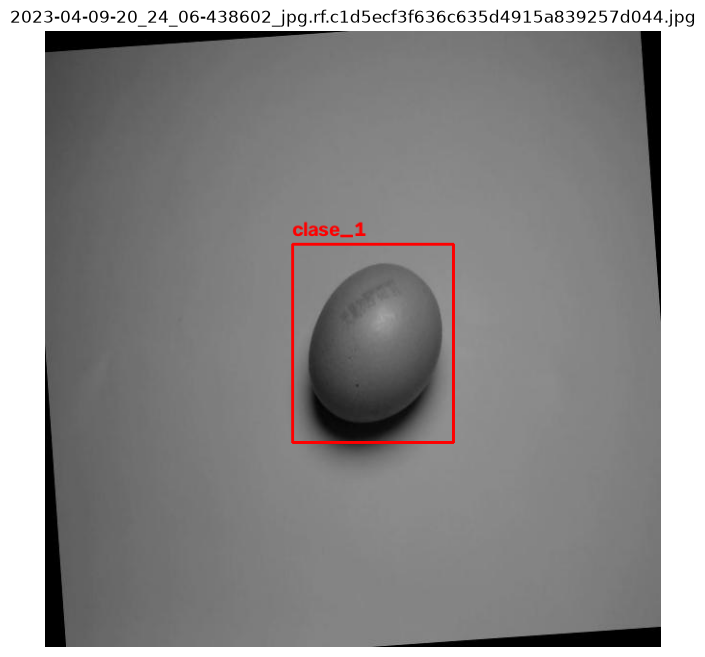

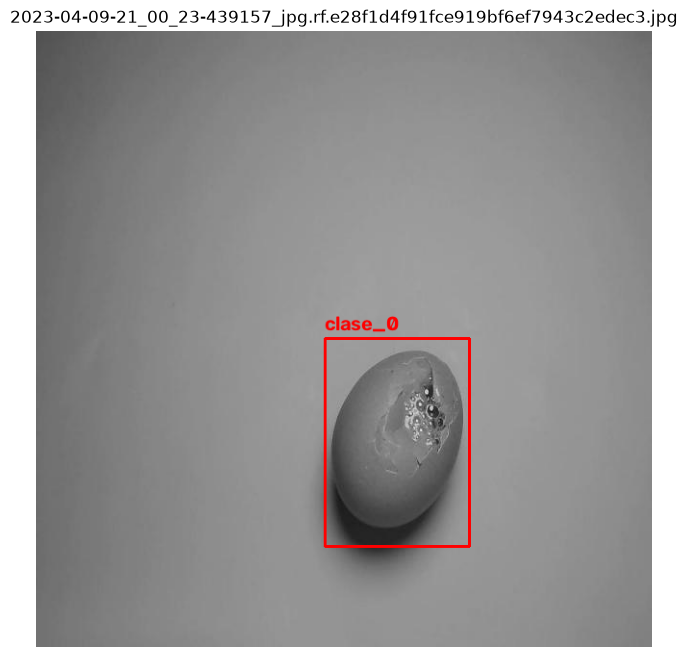

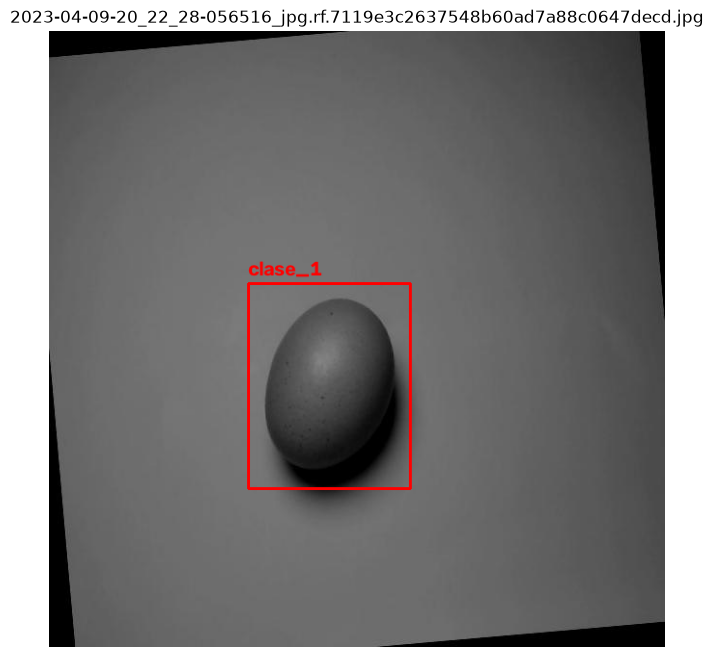

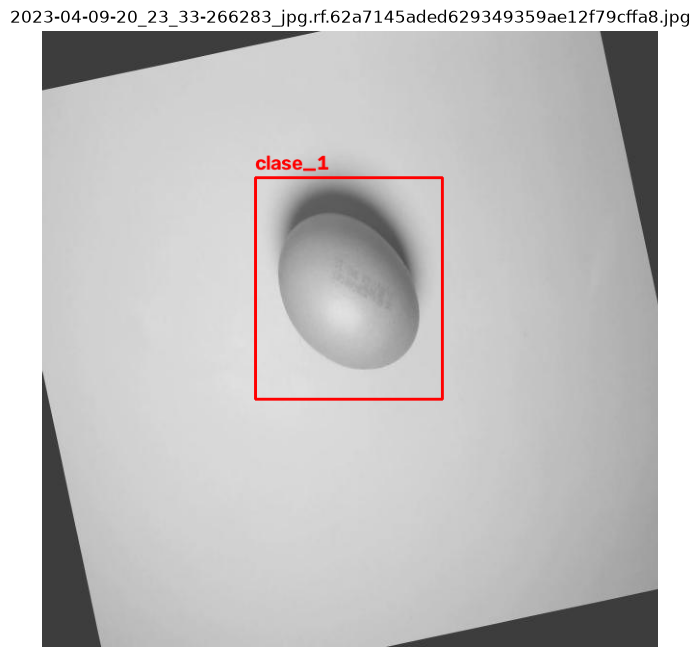

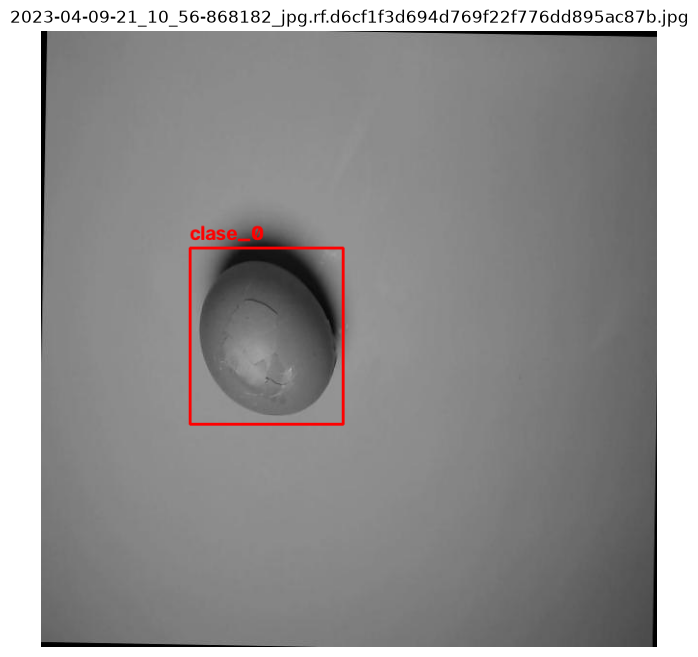

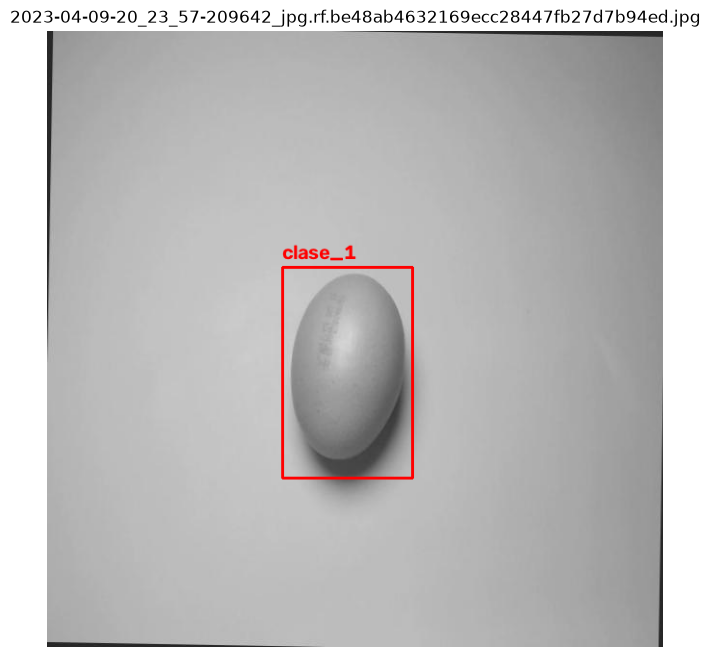

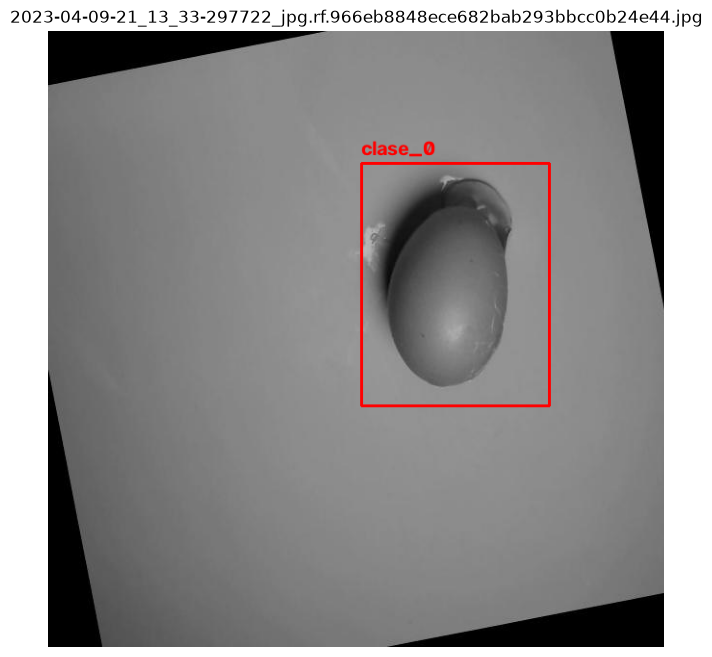

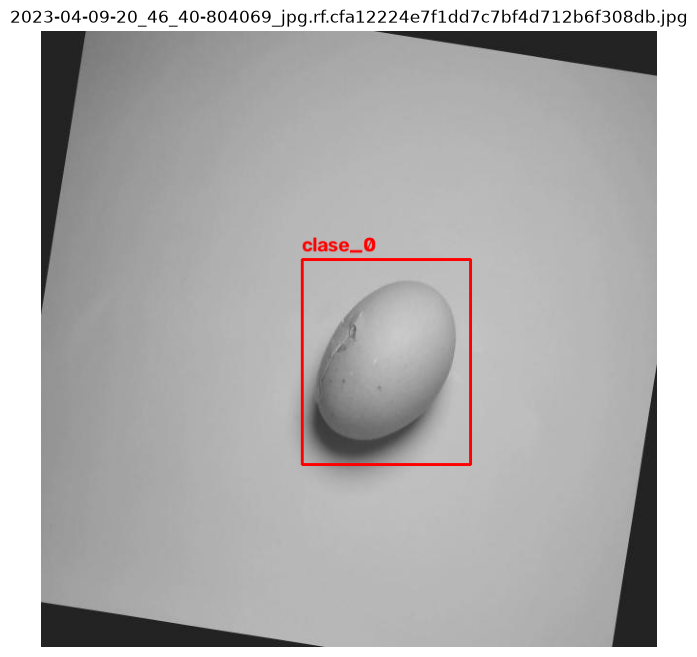

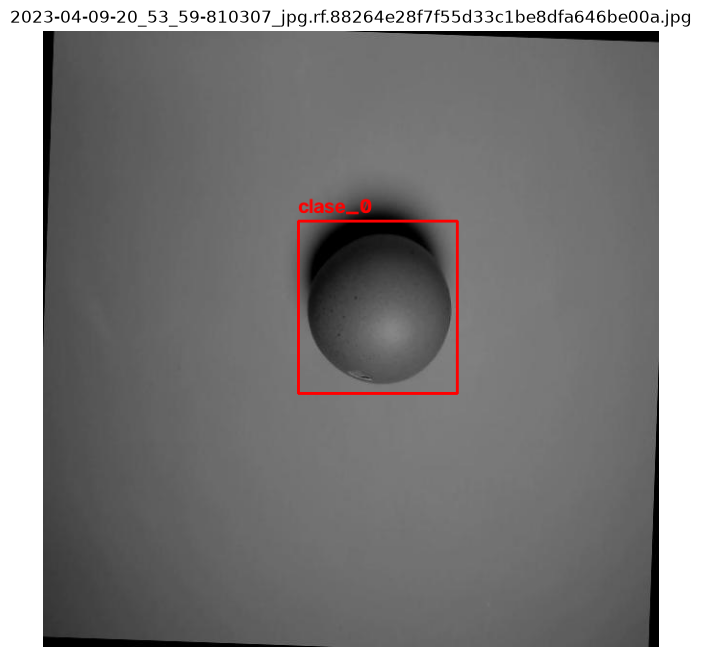

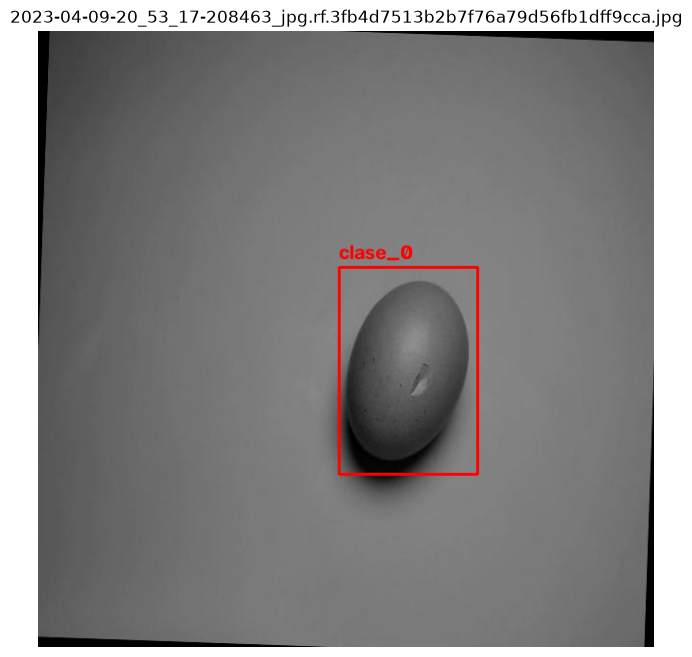

In [4]:
# Mostrar 10 imagenes aleatorias con sus etiquetas
sample_count = min(10, len(pairs))
random_images = random.sample(pairs, sample_count)
print(f'Se muestran {sample_count} imagenes aleatorias.')

for image_path, labels in random_images:
    image = cv2.imread(str(image_path))
    if image is None:
        print(f'No se pudo leer: {image_path}')
        continue

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width = image.shape[:2]
    for label in labels:
        class_value, center_x, center_y, box_width, box_height = map(float, label.split())
        x1 = int((center_x - box_width / 2) * width)
        y1 = int((center_y - box_height / 2) * height)
        x2 = int((center_x + box_width / 2) * width)
        y2 = int((center_y + box_height / 2) * height)
        class_index = int(class_value)
        cv2.rectangle(image_rgb, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(
            image_rgb,
            CLASS_NAMES[class_index],
            (x1, max(20, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 0, 0),
            2,
        )

    plt.figure(figsize=(8, 8))
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.title(image_path.name)
    plt.show()

# 5. Configuracion del modelo y busqueda de hiperparametros

In [5]:
# Configuracion del modelo y de la busqueda
WEIGHTS = 'yolo11n.pt'
DEVICE = '0' if torch.cuda.is_available() else 'cpu'
TRIALS = 15
EPOCHS = 500
IMAGE_SIZE = 640
BATCH_SIZE = 32 if torch.cuda.is_available() else 4
WORKERS = 2
PATIENCE = 20
SEARCH_SPACE = {
    'lr0': [0.0005, 0.001, 0.005],
    'lrf': [0.01, 0.05, 0.1],
    'weight_decay': [0.0001, 0.0005, 0.001],
    'hsv_h': [0.01, 0.02],
    'hsv_s': [0.5, 0.7],
    'hsv_v': [0.3, 0.5],
    'degrees': [0.0, 5.0],
    'scale': [0.3, 0.5],
    'fliplr': [0.0, 0.5],
    'mosaic': [0.5, 1.0],
    'mixup': [0.0, 0.1],
    'dropout': [0.0, 0.1],
}
RESULTS_FILE = OUTPUT_ROOT / 'search_results.json'
print('Dispositivo:', DEVICE)
print('Clases:', dict(enumerate(CLASS_NAMES)))

Dispositivo: 0
Clases: {0: 'clase_0', 1: 'clase_1'}


# 6. Declaracion de los modelos

In [6]:
# Declaracion de los modelos

def declare_model(weights):
    return YOLO(str(weights))


def trial_configuration(trial):
    return {
        name: random.Random(SEED + trial).choice(values)
        for name, values in SEARCH_SPACE.items()
    }


print('Modelo base:', WEIGHTS)
print('Funcion de declaracion lista para', TRIALS, 'pruebas')

Modelo base: yolo11n.pt
Funcion de declaracion lista para 15 pruebas


# 7. Entrenamiento de los modelos

In [ ]:
# Entrenamiento de los modelos
results = json.loads(RESULTS_FILE.read_text()) if RESULTS_FILE.exists() else []
completed_trials = {item['trial'] for item in results}

for trial in range(1, TRIALS + 1):
    if trial in completed_trials:
        print(f'Trial {trial}/{TRIALS} ya registrado; se omite.')
        continue

    run_name = f'random_trial_{trial:03d}'
    run_dir = RUNS_ROOT / run_name
    last_checkpoint = run_dir / 'weights' / 'last.pt'
    best_checkpoint = run_dir / 'weights' / 'best.pt'
    previous_best = sorted(results, key=lambda item: item['score'], reverse=True)[:3]
    initial_weights = WEIGHTS if not previous_best else previous_best[(trial - 1) % len(previous_best)]['weights']
    config = trial_configuration(trial)

    if last_checkpoint.exists():
        print(f'Reanudando {run_name} desde {last_checkpoint}')
        model = declare_model(last_checkpoint)
        model.train(resume=True)
        initialization = str(last_checkpoint)
    else:
        print(f'Iniciando {run_name} desde {initial_weights}')
        model = declare_model(initial_weights)
        model.train(
            data=str(DATASET_ROOT / 'dataset.yaml'),
            epochs=EPOCHS,
            imgsz=IMAGE_SIZE,
            batch=BATCH_SIZE,
            device=DEVICE,
            workers=WORKERS,
            patience=PATIENCE,
            seed=SEED + trial,
            project=str(RUNS_ROOT),
            name=run_name,
            exist_ok=True,
            optimizer='AdamW',
            amp=True,
            save_period=5,
            **config,
        )
        initialization = initial_weights

    if not best_checkpoint.exists():
        raise FileNotFoundError(f'No se encontro {best_checkpoint}')
    metrics = declare_model(best_checkpoint).val(
        data=str(DATASET_ROOT / 'dataset.yaml'),
        split='val',
        imgsz=IMAGE_SIZE,
        device=DEVICE,
    )
    score = float(metrics.box.map)
    results.append({
        'trial': trial,
        'score': score,
        'weights': str(best_checkpoint),
        'initialization': initialization,
        'hyperparameters': config,
    })
    results = sorted(results, key=lambda item: item['score'], reverse=True)
    RESULTS_FILE.write_text(json.dumps(results, indent=2))
    print(f'Trial {trial}/{TRIALS}: mAP50-95 de validacion={score:.5f}')

results = sorted(results, key=lambda item: item['score'], reverse=True)
print(f'Total de modelos entrenados: {len(results)}')

# 8. Comparacion de los modelos

In [ ]:
# Comparacion de los modelos
if not results:
    raise RuntimeError('Ejecuta primero la celda de entrenamiento.')

results = sorted(results, key=lambda item: item['score'], reverse=True)
comparison = pd.DataFrame([
    {
        'ranking': rank,
        'trial': item['trial'],
        'mAP50-95 validacion': item['score'],
        'modelo': item['weights'],
    }
    for rank, item in enumerate(results, start=1)
])
display(comparison)

for rank, item in enumerate(results[:3], start=1):
    destination = OUTPUT_ROOT / f'model_{rank}'
    destination.mkdir(parents=True, exist_ok=True)
    shutil.copy2(item['weights'], destination / 'best.pt')
    metadata = {
        'rank': rank,
        'trial': item['trial'],
        'metric': 'mAP50-95',
        'score': item['score'],
        'hyperparameters': item['hyperparameters'],
        'class_names': CLASS_NAMES,
    }
    (destination / 'configuration.json').write_text(json.dumps(metadata, indent=2))

shutil.copy2(results[0]['weights'], PROJECT_ROOT / 'models' / 'best.pt')
print('Ganador:', PROJECT_ROOT / 'models' / 'best.pt')
print('Modelos guardados en:', OUTPUT_ROOT)

# 9. Metricas y resultados del mejor modelo

In [ ]:
# Metricas y visualizacion del mejor modelo
best_trial = results[0]
best_run = RUNS_ROOT / f"random_trial_{best_trial['trial']:03d}"
plot_files = ['results.png', 'confusion_matrix.png', 'PR_curve.png', 'F1_curve.png', 'P_curve.png', 'R_curve.png']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for axis, filename in zip(axes.flat, plot_files):
    path = best_run / filename
    if path.exists():
        axis.imshow(Image.open(path))
        axis.set_title(filename)
    else:
        axis.text(0.5, 0.5, f'No generado: {filename}', ha='center', va='center')
    axis.axis('off')
plt.tight_layout()
plt.show()

history_path = best_run / 'results.csv'
if history_path.exists():
    history = pd.read_csv(history_path)
    history.columns = history.columns.str.strip()
    display(history.tail())

best_model = declare_model(results[0]['weights'])
final_metrics = best_model.val(
    data=str(FINAL_TEST_ROOT / 'dataset.yaml'),
    split='test',
    imgsz=IMAGE_SIZE,
    device=DEVICE,
)
print(f"Modelo ganador: trial {results[0]['trial']}")
print(f"mAP50-95 final: {float(final_metrics.box.map):.5f}")
print(f"mAP50 final: {float(final_metrics.box.map50):.5f}")

final_images = sorted((FINAL_TEST_ROOT / 'images').glob('*'))
sample_images = final_images[:min(6, len(final_images))]
if sample_images:
    predictions = best_model.predict(
        source=[str(path) for path in sample_images],
        conf=0.35,
        imgsz=IMAGE_SIZE,
        device=DEVICE,
    )
    rows = (len(predictions) + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(18, 6 * rows))
    axes = [axes] if rows == 1 else axes
    for axis in axes.flat:
        axis.axis('off')
    for axis, prediction in zip(axes.flat, predictions):
        axis.imshow(prediction.plot()[..., ::-1])
    plt.tight_layout()
    plt.show()